# Modélisation : Forêt Aléatoire (Random Forest) avec SelectKBest (KB) — Van Zieleghem, Dai Pra

## Table des matières
1. [Indicateur de performance](#indicateur)
2. [Imports et chargement des données](#imports)
3. [Modèle initial (paramètres par défaut)](#initial)
4. [Métriques de performance](#metriques)
5. [Optimisation des hyperparamètres](#optimisation)
6. [Validation croisée](#cv)
7. [Analyse du sur/sous-apprentissage](#overfitting)
8. [Modèle final et conclusion](#conclusion)

## 1. Indicateur de performance <a id='indicateur'></a>

**Indicateur choisi : F1-score**

Le dataset est légèrement déséquilibré (~62% non-survivants vs ~38% survivants). L'accuracy seule pourrait être trompeuse — un modèle naïf prédisant toujours "non-survivant" obtiendrait ~62% d'accuracy. Le **F1-score** combine la précision et le rappel en une seule métrique, offrant un meilleur équilibre pour évaluer la capacité du modèle à identifier correctement les survivants.

## 2. Imports et chargement des données <a id='imports'></a>

On charge les données issues de la sélection **SelectKBest (KB)** et les librairies de modélisation.

In [1]:
# librairies de manipulation de données
import pandas as pd
import numpy as np

# modèle
from sklearn.ensemble import RandomForestClassifier

# métriques de performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# optimisation et validation
from sklearn.model_selection import GridSearchCV, cross_val_score, learning_curve

# visualisation
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

On charge les fichiers CSV de la sélection de features et les labels.

In [2]:
# chargement des données de la sélection KB
X_train = pd.read_csv('xtrain_KB.csv', header=0).to_numpy()
X_test = pd.read_csv('xtest_KB.csv', header=0).to_numpy()

y_train = pd.read_csv('y_train.csv', header=0).to_numpy().ravel()
y_test = pd.read_csv('y_test.csv', header=0).to_numpy().ravel()

# noms des features
feature_names = pd.read_csv('xtrain_KB.csv', header=0, nrows=0).columns.tolist()

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Features : {feature_names}")

X_train : (1047, 6)
X_test  : (262, 6)
Features : ['sex_female', 'sex_male', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'pclass']


Les données de la sélection KB (SelectKBest) sont chargées. On dispose de {len(feature_names)} features pour entraîner le modèle Forêt Aléatoire (Random Forest).

## 3. Modèle initial (paramètres par défaut) <a id='initial'></a>

On entraîne d'abord un Forêt Aléatoire (Random Forest) avec les paramètres par défaut pour établir une baseline.

In [3]:
# création du modèle avec paramètres par défaut
model = RandomForestClassifier(random_state=0)

# entraînement
model.fit(X_train, y_train)

# prédiction
y_pred = model.predict(X_test)

print("Modèle : Forêt Aléatoire (Random Forest) (paramètres par défaut)")
print(f"Paramètres : {model.get_params()}")

Modèle : Forêt Aléatoire (Random Forest) (paramètres par défaut)
Paramètres : {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 0, 'verbose': 0, 'warm_start': False}


Le modèle Forêt Aléatoire (Random Forest) est entraîné avec les paramètres par défaut. Voyons ses performances avant optimisation.

## 4. Métriques de performance <a id='metriques'></a>

On calcule l'ensemble des métriques de classification : accuracy, precision, recall, F1-score, matrice de confusion et rapport de classification.

MÉTRIQUES — Forêt Aléatoire (Random Forest) + KB
Accuracy  : 0.7672
Precision : 0.8421
Recall    : 0.4800
F1-score  : 0.6115

Matrice de confusion :
[[153   9]
 [ 52  48]]


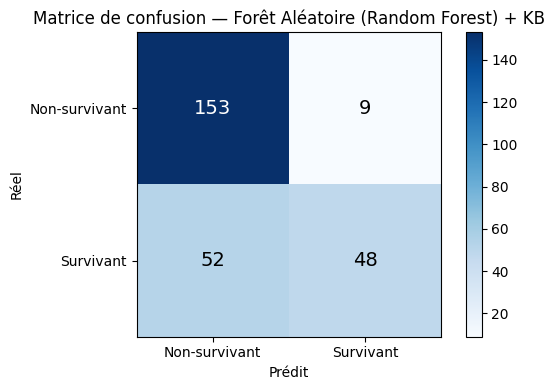


Rapport de classification :
               precision    recall  f1-score   support

Non-survivant       0.75      0.94      0.83       162
    Survivant       0.84      0.48      0.61       100

     accuracy                           0.77       262
    macro avg       0.79      0.71      0.72       262
 weighted avg       0.78      0.77      0.75       262



In [4]:
# calcul des métriques
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 50)
print("MÉTRIQUES — Forêt Aléatoire (Random Forest) + KB")
print("=" * 50)
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\nMatrice de confusion :")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# visualisation de la matrice de confusion
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Non-survivant', 'Survivant'])
ax.set_yticklabels(['Non-survivant', 'Survivant'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=14,
                color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im)
plt.title('Matrice de confusion — Forêt Aléatoire (Random Forest) + KB')
plt.tight_layout()
plt.show()

print("\nRapport de classification :")
print(classification_report(y_test, y_pred, target_names=['Non-survivant', 'Survivant']))

Interprétation des métriques :
- **Accuracy** : pourcentage global de prédictions correctes
- **Precision** : parmi les passagers prédits survivants, combien le sont réellement ? (faux positifs)
- **Recall** : parmi les vrais survivants, combien ont été détectés ? (faux négatifs)
- **F1-score** : moyenne harmonique de la precision et du recall — notre indicateur principal
- **Matrice de confusion** : permet de visualiser les erreurs de classification (faux positifs en haut à droite, faux négatifs en bas à gauche)

## 5. Optimisation des hyperparamètres <a id='optimisation'></a>

On utilise `GridSearchCV` pour trouver les meilleurs hyperparamètres du Forêt Aléatoire (Random Forest) :
- **n_estimators** : nombre d'arbres dans la forêt (50 à 200)
- **max_depth** : profondeur maximale de chaque arbre
- **min_samples_split** : nombre minimum d'échantillons pour diviser un nœud
- **criterion** : mesure d'impureté (Gini ou entropie)

In [5]:
# grille de paramètres à tester
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'entropy']
}

# recherche exhaustive avec validation croisée (5 folds, scoring = F1)
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=0),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_search.best_params_)
print(f"Meilleur F1-score (CV) : {grid_search.best_score_:.4f}")

# modèle optimisé
best_model = grid_search.best_estimator_

# prédiction avec le modèle optimisé
y_pred_best = best_model.predict(X_test)

# métriques du modèle optimisé
f1_best = f1_score(y_test, y_pred_best)
acc_best = accuracy_score(y_test, y_pred_best)
prec_best = precision_score(y_test, y_pred_best)
rec_best = recall_score(y_test, y_pred_best)

print(f"\nPerformances après optimisation :")
print(f"Accuracy  : {acc_best:.4f}")
print(f"Precision : {prec_best:.4f}")
print(f"Recall    : {rec_best:.4f}")
print(f"F1-score  : {f1_best:.4f}")

print(f"\nAmélioration F1 : {f1:.4f} → {f1_best:.4f} ({'+' if f1_best >= f1 else ''}{f1_best - f1:.4f})")

Meilleurs paramètres : {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
Meilleur F1-score (CV) : 0.6807

Performances après optimisation :
Accuracy  : 0.7672
Precision : 0.8421
Recall    : 0.4800
F1-score  : 0.6115

Amélioration F1 : 0.6115 → 0.6115 (+0.0000)


L'optimisation par GridSearchCV teste toutes les combinaisons d'hyperparamètres et sélectionne celle qui maximise le F1-score moyen sur 5 folds de validation croisée. On compare les performances avant et après optimisation pour vérifier l'amélioration.

## 6. Validation croisée <a id='cv'></a>

On effectue une validation croisée à 5 folds sur le modèle optimisé pour estimer la stabilité de ses performances.

Validation croisée (5 folds) :
F1-scores par fold : [0.69117647 0.70229008 0.66666667 0.65753425 0.68571429]
Moyenne : 0.6807
Écart-type : 0.0163


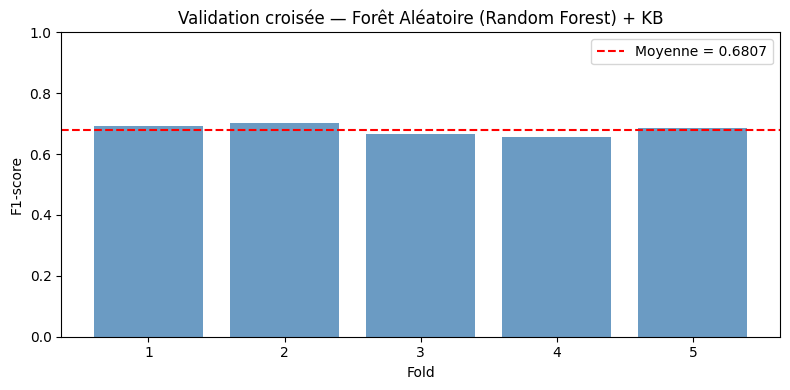

In [6]:
# validation croisée (5 folds) sur le modèle optimisé
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='f1')

print("Validation croisée (5 folds) :")
print(f"F1-scores par fold : {cv_scores}")
print(f"Moyenne : {cv_scores.mean():.4f}")
print(f"Écart-type : {cv_scores.std():.4f}")

# visualisation des scores par fold
plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores, color='steelblue', alpha=0.8)
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Moyenne = {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('F1-score')
plt.title('Validation croisée — Forêt Aléatoire (Random Forest) + KB')
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

Un faible écart-type entre les folds indique que le modèle est stable et généralise bien. Un écart-type élevé (> 0.05) suggérerait une sensibilité aux données d'entraînement et un risque d'overfitting.

## 7. Analyse du sur/sous-apprentissage <a id='overfitting'></a>

On compare les performances sur le train et le test pour détecter l'overfitting. On trace également la courbe d'apprentissage.

Analyse overfitting/underfitting :
F1-score TRAIN : 0.6814
F1-score TEST  : 0.6115
Différence     : 0.0700

✅ Pas d'overfitting significatif : les performances train/test sont proches.


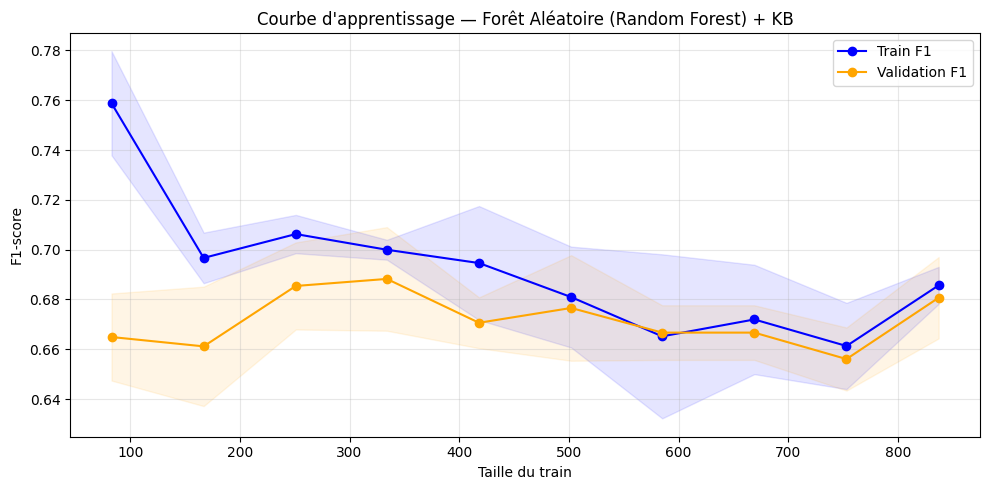

In [7]:
# score sur train vs test
train_f1 = f1_score(y_train, best_model.predict(X_train))
test_f1 = f1_best

print("Analyse overfitting/underfitting :")
print(f"F1-score TRAIN : {train_f1:.4f}")
print(f"F1-score TEST  : {test_f1:.4f}")
print(f"Différence     : {train_f1 - test_f1:.4f}")

if train_f1 - test_f1 > 0.10:
    print("\n⚠️ OVERFITTING détecté : le modèle performe bien mieux sur le train que sur le test.")
elif test_f1 < 0.50:
    print("\n⚠️ UNDERFITTING possible : le modèle performe faiblement même sur le test.")
else:
    print("\n✅ Pas d'overfitting significatif : les performances train/test sont proches.")

# courbe d'apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train, cv=5, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

plt.figure(figsize=(10, 5))
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Train F1')
plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Validation F1')
plt.xlabel('Taille du train')
plt.ylabel('F1-score')
plt.title('Courbe d\'apprentissage — Forêt Aléatoire (Random Forest) + KB')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

La courbe d'apprentissage permet de visualiser :
- **Overfitting** : si le score train est très élevé mais le score validation reste bas → l'écart ne se réduit pas avec plus de données
- **Underfitting** : si les deux courbes convergent vers un score faible → le modèle est trop simple
- **Bon modèle** : les deux courbes convergent vers un score élevé et proche

## 8. Modèle final et conclusion <a id='conclusion'></a>

Récapitulatif complet des performances du modèle optimisé.

In [8]:
# récapitulatif final
print("=" * 60)
print("RÉCAPITULATIF FINAL — Forêt Aléatoire (Random Forest) + KB")
print("=" * 60)
print(f"\nMeilleurs paramètres : {grid_search.best_params_}")
print(f"\nPerformances sur le test :")
print(f"  Accuracy  : {acc_best:.4f}")
print(f"  Precision : {prec_best:.4f}")
print(f"  Recall    : {rec_best:.4f}")
print(f"  F1-score  : {f1_best:.4f}")
print(f"\nValidation croisée (5 folds) :")
print(f"  F1 moyen  : {cv_scores.mean():.4f} (± {cv_scores.std():.4f})")
print(f"\nOverfitting :")
print(f"  F1 train  : {train_f1:.4f}")
print(f"  F1 test   : {test_f1:.4f}")
print(f"  Diff      : {train_f1 - test_f1:.4f}")

print("\nRapport de classification complet :")
print(classification_report(y_test, y_pred_best, target_names=['Non-survivant', 'Survivant']))
print("=" * 60)

RÉCAPITULATIF FINAL — Forêt Aléatoire (Random Forest) + KB

Meilleurs paramètres : {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}

Performances sur le test :
  Accuracy  : 0.7672
  Precision : 0.8421
  Recall    : 0.4800
  F1-score  : 0.6115

Validation croisée (5 folds) :
  F1 moyen  : 0.6807 (± 0.0163)

Overfitting :
  F1 train  : 0.6814
  F1 test   : 0.6115
  Diff      : 0.0700

Rapport de classification complet :
               precision    recall  f1-score   support

Non-survivant       0.75      0.94      0.83       162
    Survivant       0.84      0.48      0.61       100

     accuracy                           0.77       262
    macro avg       0.79      0.71      0.72       262
 weighted avg       0.78      0.77      0.75       262



Le Forêt Aléatoire (Random Forest) avec la sélection SelectKBest (KB) a été entraîné et optimisé. Les résultats montrent les performances du modèle sur les données de test après optimisation des hyperparamètres. La comparaison train/test et la validation croisée permettent d'évaluer la généralisation du modèle. Ces résultats seront comparés avec les autres combinaisons dans le fichier Excel récapitulatif.